# Getting Tuolumne Data

In [1]:
import geopandas as gpd
import glob
import rasterio
import rioxarray
import os
import numpy as np

import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping

In [2]:
# create data stack
from pathlib import Path
main_folder = Path('../Dataset/Data/SWE')
tif_files = []

In [3]:
for year_folder in main_folder.iterdir():
    for tif in year_folder.glob("*.tif"):
        tif_files.append(tif)

In [4]:
tif_files = sorted(tif_files)
# tif_files

In [5]:
tif_data = []
for tif in tif_files:
    with rasterio.open(tif) as src:
        tif_data.append(src.read(1))

In [6]:
data_stack = np.stack(tif_data)

In [7]:
# check
print("stack shape:", data_stack.shape)

stack shape: (48, 1339, 1374)


In [8]:
# check
# data_stack

In [9]:
# create time array
time = []
for tif  in tif_files:
    file_name = tif.name
    date = file_name[2:10]
    from pandas import to_datetime
    date = to_datetime(date)
    time.append(date)

In [10]:
# check
# time

In [11]:
# create lat/lon arrays
longs = [];
lats = [];

file = rasterio.open(tif_files[0])
data = file.read(1)
height, width = data.shape

rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

transform = file.transform
longs = transform.c + cols * transform.a + rows * transform.b
lats  = transform.f + cols * transform.d + rows * transform.e

lats_1d = lats[:, 0]  # all rows, first column
longs_1d = longs[0, :]  # first row, all columns


In [12]:
# create SWE dataset
ds =  xr.DataArray(data_stack, 
    coords={"time": time, "lat": lats_1d, "lon": longs_1d},
    dims=("time", "lat", "lon"), name = 'SWE')

ds.attrs = {
    "long_name": "Snow Water Equivalent",
    "units": "millimeters h20"
}

In [13]:
# ds

In [14]:
one_day = ds.sel(time='20130525')
# one_day

In [15]:
# read shapefile
tuolumne_boundary = gpd.read_file("../Dataset/Metadata/tuolumne_extent.json")
# change crs to match tif data
tuolumne_boundary = tuolumne_boundary.to_crs("epsg:26911")

In [16]:
tuolumne_boundary

,geometry
0,"POLYGON ((238646.787 4179266.12, 238646.904 42..."


In [17]:
poly = tuolumne_boundary.geometry.to_list()
tuolumne_clipped = ds.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
tuolumne_clipped = tuolumne_clipped.rio.write_crs('epsg:26911', inplace=True)
tuolumne_clipped = tuolumne_clipped.rio.clip(poly, crs='epsg:26911')

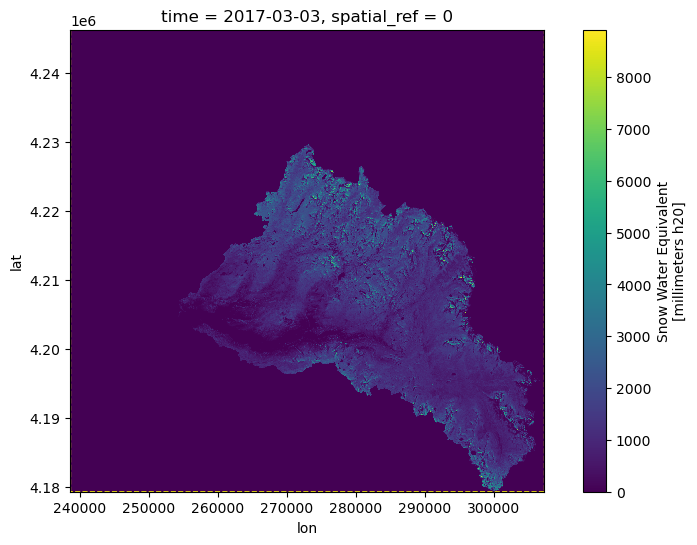

In [18]:
# plot for tuolumne basin
fig, ax = plt.subplots(figsize=(10,6))

one_day = ds.sel(time='2017/03/03', method='nearest')
one_day.plot(ax=ax)

tuolumne_boundary.plot(ax=ax, edgecolor='yellow', linestyle='--', facecolor='none');
ax.set_aspect(1)

In [19]:
ds_mean = ds.mean(dim= ('lat', 'lon'))

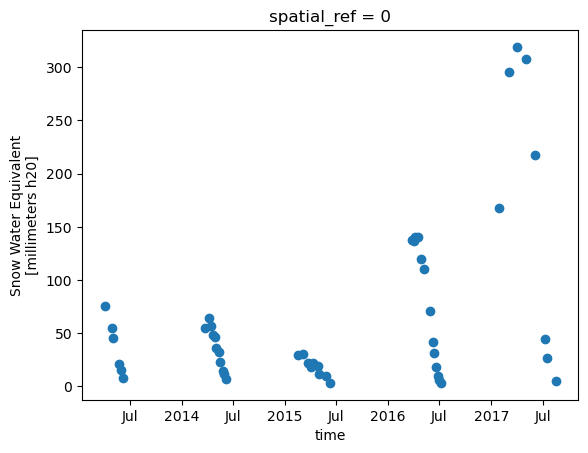

In [20]:
ds_mean.plot(marker='o', linestyle='none')